# Buscador semántico de películas - Extracción y exploración de datos

## Objetivo
Construir un dataset inicial de películas utilizando la API de TMDB que servirá como base para un sistema de búsqueda semántica.

## Qué vamos a hacer en este notebook
1. Conectarnos a la API de TMDB
2. Descargar películas populares
3. Explorar los datos obtenidos
4. Enriquecer la información con detalles adicionales
5. Construir una representación textual por película

Este dataset será utilizado posteriormente para:
- TF-IDF (baseline léxico)
- Embeddings (búsqueda semántica)

## 🔐 Configuración de la API (requerido)

Este notebook utiliza la API de TMDB.

Para ejecutarlo:

1. Crear una cuenta en TMDB
2. Obtener un Bearer Token (API Read Access Token)
3. En Google Colab:
   - Ir al panel izquierdo → "Secrets"
   - Crear un nuevo secret:
     - Name: TMDB_BEARER
     - Value: <tu token>
   - Activar "Notebook access"

Sin este paso, las requests a la API fallarán.

In [42]:
!pip install -q requests pandas pyarrow

In [2]:
import requests
import pandas as pd
import time
from typing import Dict, List, Any

In [43]:
# Configuración de la API
from google.colab import userdata

TMDB_BEARER = userdata.get("TMDB_BEARER")

if not TMDB_BEARER:
    raise ValueError("No se encontró TMDB_BEARER en los secrets de Colab")

HEADERS = {
    "accept": "application/json",
    "Authorization": f"Bearer {TMDB_BEARER}"
}

BASE_URL = "https://api.themoviedb.org/3"

In [44]:
def tmdb_get(endpoint: str, params: Dict[str, Any] | None = None) -> Dict[str, Any]:
    """
    Realiza una request GET a la API de TMDB y devuelve la respuesta en formato JSON.

    Parámetros:
    - endpoint: endpoint de la API, por ejemplo '/movie/popular'
    - params: diccionario opcional con parámetros de la consulta

    Retorna:
    - Un diccionario con la respuesta JSON de la API
    """
    url = f"{BASE_URL}{endpoint}"

    try:
        response = requests.get(url, headers=HEADERS, params=params, timeout=20)
        response.raise_for_status()
        return response.json()

    except requests.exceptions.RequestException as e:
        print(f"Error al consultar TMDB: {url}")
        print(f"Parámetros: {params}")
        print(f"Detalle del error: {e}")
        raise

In [45]:
# Traemos la primera página de películas populares
popular_page_1 = tmdb_get(
    "/movie/popular",
    params={"language": "en-US", "page": 1}
)

# Estructura general del JSON
popular_page_1.keys()


dict_keys(['page', 'results', 'total_pages', 'total_results'])

In [46]:
# Inspeccionamos algunos resultados
popular_page_1["results"][:3]

[{'adult': False,
  'backdrop_path': '/1x9e0qWonw634NhIsRdvnneeqvN.jpg',
  'genre_ids': [10749, 18],
  'id': 1523145,
  'original_language': 'ru',
  'original_title': 'Твоё сердце будет разбито',
  'overview': 'High school student Polina is saved from bullying at her new school and makes a deal with the main bully Bars: he must pretend to be her boyfriend and protect her, and she must do everything he says. During this game, the couple develops real feelings, but her family and classmates have reasons to separate the lovers.',
  'popularity': 1037.0135,
  'poster_path': '/7wIBfBl2gejt6xHxNSK0reVIm7E.jpg',
  'release_date': '2026-03-26',
  'title': 'Your Heart Will Be Broken',
  'video': False,
  'vote_average': 6.741,
  'vote_count': 29},
 {'adult': False,
  'backdrop_path': '/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg',
  'genre_ids': [878, 12, 14],
  'id': 83533,
  'original_language': 'en',
  'original_title': 'Avatar: Fire and Ash',
  'overview': "In the wake of the devastating war against th

In [47]:
# Convertimos la lista de películas en DataFrame
page_1_df = pd.DataFrame(popular_page_1["results"])

# Vemos primeras filas
page_1_df.head()


,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,"[10749, 18]",1523145,ru,Твоё сердце будет разбито,High school student Polina is saved from bully...,1037.0135,/7wIBfBl2gejt6xHxNSK0reVIm7E.jpg,2026-03-26,Your Heart Will Be Broken,False,6.741,29
1,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,"[878, 12, 14]",83533,en,Avatar: Fire and Ash,In the wake of the devastating war against the...,499.5353,/bRBeSHfGHwkEpImlhxPmOcUsaeg.jpg,2025-12-17,Avatar: Fire and Ash,False,7.330,2149
2,False,/uNToXatdunyvWXyXMrTI1nLvh6r.jpg,"[35, 878, 80]",1115544,en,Mike & Nick & Nick & Alice,Two gangsters and the woman they love try to s...,359.4255,/7F0jc75HrSkLVcvOXR2FXAIwuEv.jpg,2026-03-14,Mike & Nick & Nick & Alice,False,6.744,119
3,False,/nHxWyy18SvAZ8jJeemtS8k1UNjM.jpg,"[28, 80, 53]",1290821,en,Shelter,A man living in self-imposed exile on a remote...,299.9839,/buPFnHZ3xQy6vZEHxbHgL1Pc6CR.jpg,2026-01-28,Shelter,False,6.736,454
4,False,/tq3h43fZy0H80vzf47MAY7R9Mxo.jpg,"[16, 35, 10751]",1297842,en,GOAT,A small goat with big dreams gets a once-in-a-...,284.0079,/wfuqMlaExcoYiUEvKfVpUTt1v4u.jpg,2026-02-11,GOAT,False,7.700,265


In [48]:
# Columnas disponibles
page_1_df.columns.tolist()

['adult',
 'backdrop_path',
 'genre_ids',
 'id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'release_date',
 'title',
 'video',
 'vote_average',
 'vote_count']

In [49]:
# Seleccionamos columnas relevantes para análisis
page_1_df[[
    "id",
    "title",
    "original_language",
    "release_date",
    "overview",
    "genre_ids",
    "popularity"
]].head(10)

,id,title,original_language,release_date,overview,genre_ids,popularity
0,1523145,Your Heart Will Be Broken,ru,2026-03-26,High school student Polina is saved from bully...,"[10749, 18]",1037.0135
1,83533,Avatar: Fire and Ash,en,2025-12-17,In the wake of the devastating war against the...,"[878, 12, 14]",499.5353
2,1115544,Mike & Nick & Nick & Alice,en,2026-03-14,Two gangsters and the woman they love try to s...,"[35, 878, 80]",359.4255
3,1290821,Shelter,en,2026-01-28,A man living in self-imposed exile on a remote...,"[28, 80, 53]",299.9839
4,1297842,GOAT,en,2026-02-11,A small goat with big dreams gets a once-in-a-...,"[16, 35, 10751]",284.0079
5,1171145,Crime 101,en,2026-02-11,When an elusive thief whose high-stakes heists...,"[80, 53]",261.1322
6,1084187,Pretty Lethal,en,2026-03-13,A troupe of ballerinas find themselves fightin...,"[28, 53, 10402]",250.3557
7,687163,Project Hail Mary,en,2026-03-15,Science teacher Ryland Grace wakes up on a spa...,"[878, 12]",249.2093
8,1159559,Scream 7,en,2026-02-25,When a new Ghostface killer emerges in the qui...,"[27, 9648, 80]",232.1837
9,1327819,Hoppers,en,2026-03-04,Scientists have discovered how to 'hop' human ...,"[16, 10751, 878, 35, 12]",205.1130


La función anterior está bien, pero puede mejorarase:

*   Manejo de errores
*   Guardar metadatos de origen
*   Validar num_pages por si se pone algo que no corresponde
*   Usar el total_pages: Porque si pedís más páginas de las que existen, o si cambia el total, tu función podría ser más inteligente.
*   **PENSAR EN QUÉ DATASET QUIERO CONSTRUIR**, esto es clave, el endpoint /movie/popular sirve para prototipo, pero para un buscador semántico, más adelante eso puede ser un problema, porque:
    *   el catálogo no es diverso
    *   faltan películas menos conocidas
    *   el espacio semántico queda empobrecido

El endpoint elegido define el tipo de corpus.

Las estrategias posibles pueden ser: seguir con /movie/popular ya que es lo más sencillo en el momento inicial, combinar varios endpoints y juntar todo para que el corpus quede mas diverso, usar búsqueda por discovery se podría de esta manera crear un corpus mas representativo(películas de distintos años y géneros), o hacer un muestreo por décadas o géneros para que el corpus sea mas balanceado.


**En esta etapa descargamos varias páginas de películas populares desde TMDB para construir un corpus inicial. Este enfoque es útil para prototipar el pipeline, aunque introduce un sesgo hacia películas más conocidas o recientes. Más adelante podremos ampliar el corpus usando otros endpoints o criterios de muestreo.**




In [50]:
def get_popular_movies(num_pages: int = 5, language: str = "en-US") -> pd.DataFrame:
    """
    Descarga múltiples páginas de películas populares desde TMDB.

    Parámetros:
    - num_pages: cantidad de páginas a descargar
    - language: idioma en el que se solicita la información

    Retorna:
    - Un DataFrame con las películas descargadas, sin duplicados por id
    """
    if num_pages < 1:
        raise ValueError("num_pages debe ser mayor o igual a 1")

    movies = []

    for page in range(1, num_pages + 1):
        try:
            print(f"Descargando página {page}...")

            data = tmdb_get(
                "/movie/popular",
                params={"language": language, "page": page}
            )

            results = data.get("results", [])

            for movie in results:
                movie["source_page"] = page

            movies.extend(results)
            time.sleep(0.2)

        except Exception as e:
            print(f"Error al descargar la página {page}: {e}")

    df = pd.DataFrame(movies)
    df = df.drop_duplicates(subset="id").reset_index(drop=True)

    return df

## Construcción del dataset inicial

En esta etapa construimos un dataset inicial de películas utilizando el endpoint de películas populares de TMDB.

Este enfoque permite obtener rápidamente un conjunto de datos consistente y con buena calidad de información textual, lo cual es útil para prototipar el sistema.

Sin embargo, introduce un sesgo hacia películas recientes y mainstream. En etapas posteriores del proyecto, se evaluará el impacto de construir un corpus más balanceado en términos de géneros y periodos temporales sobre la calidad de la recuperación.

In [51]:
# Descargamos dataset inicial
movies_df = get_popular_movies(num_pages=60)

# Cantidad de películas obtenidas
movies_df.shape

Descargando página 1...
Descargando página 2...
Descargando página 3...
Descargando página 4...
Descargando página 5...
Descargando página 6...
Descargando página 7...
Descargando página 8...
Descargando página 9...
Descargando página 10...
Descargando página 11...
Descargando página 12...
Descargando página 13...
Descargando página 14...
Descargando página 15...
Descargando página 16...
Descargando página 17...
Descargando página 18...
Descargando página 19...
Descargando página 20...
Descargando página 21...
Descargando página 22...
Descargando página 23...
Descargando página 24...
Descargando página 25...
Descargando página 26...
Descargando página 27...
Descargando página 28...
Descargando página 29...
Descargando página 30...
Descargando página 31...
Descargando página 32...
Descargando página 33...
Descargando página 34...
Descargando página 35...
Descargando página 36...
Descargando página 37...
Descargando página 38...
Descargando página 39...
Descargando página 40...
Descargan

(1200, 15)

In [52]:
# Exploración inicial
# Vemos algunas columnas clave
movies_df[["id", "title", "original_language", "release_date"]].head(10)

,id,title,original_language,release_date
0,1523145,Your Heart Will Be Broken,ru,2026-03-26
1,83533,Avatar: Fire and Ash,en,2025-12-17
2,1115544,Mike & Nick & Nick & Alice,en,2026-03-14
3,1290821,Shelter,en,2026-01-28
4,1297842,GOAT,en,2026-02-11
5,1171145,Crime 101,en,2026-02-11
6,1084187,Pretty Lethal,en,2026-03-13
7,687163,Project Hail Mary,en,2026-03-15
8,1159559,Scream 7,en,2026-02-25
9,1327819,Hoppers,en,2026-03-04


In [53]:
# Tipos de datos
movies_df.info()
movies_df.isna().sum().sort_values(ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              1200 non-null   bool   
 1   backdrop_path      1178 non-null   object 
 2   genre_ids          1200 non-null   object 
 3   id                 1200 non-null   int64  
 4   original_language  1200 non-null   object 
 5   original_title     1200 non-null   object 
 6   overview           1200 non-null   object 
 7   popularity         1200 non-null   float64
 8   poster_path        1197 non-null   object 
 9   release_date       1200 non-null   object 
 10  title              1200 non-null   object 
 11  video              1200 non-null   bool   
 12  vote_average       1200 non-null   float64
 13  vote_count         1200 non-null   int64  
 14  source_page        1200 non-null   int64  
dtypes: bool(2), float64(2), int64(3), object(8)
memory usage: 124.3+ KB


,0
backdrop_path,22
poster_path,3
adult,0
id,0
original_language,0
original_title,0
genre_ids,0
overview,0
popularity,0
release_date,0


In [54]:
# Distribución de idiomas
movies_df["original_language"].value_counts().head(10)
# # movies_df["original_language"].value_counts(normalize=True).head(10) #Proporción

,count
original_language,
en,960
ja,44
ko,28
fr,26
es,22
it,18
zh,17
tl,12
hi,10


### Distribución de idiomas

La mayoría de las películas en el dataset tienen como idioma original el inglés (~90%), con una menor presencia de otros idiomas como japonés, coreano, francés y español.

Cabe destacar que, aunque las películas provienen de distintos países, las descripciones (`overview`) se solicitaron en inglés (`language="en-US"`), por lo que el corpus textual es en gran medida monolingüe.

Esto simplifica el análisis inicial, pero limita la exploración de escenarios verdaderamente multilingües, lo cual será considerado en etapas posteriores del proyecto.




In [55]:
# Cuántas películas NO tienen sinopsis
# movies_df["overview"].isna().sum() #---> Obtengo np.int64(0) es decir no hay NaN

#Al correr:
((movies_df["overview"].isna()) | (movies_df["overview"].str.strip() == "")).sum() # Obtengo np.int64(8) - Significa que hay 8 películas cuyo overview está vacío o solo tiene espacios.

np.int64(8)

### Calidad de la sinopsis (`overview`)

Al revisar la columna `overview`, no se encontraron valores nulos (`NaN`). Sin embargo, sí aparecieron algunos casos con sinopsis vacías o compuestas solo por espacios.

Esto es importante porque, para tareas de búsqueda léxica y semántica, una película sin texto descriptivo aporta muy poca información y puede afectar la calidad de la recuperación.

In [56]:
# Longitud de las sinopsis
movies_df["overview"].str.len().describe()

,overview
count,1200.000000
mean,275.910833
std,136.193607
min,0.000000
25%,173.750000
50%,246.500000
75%,352.250000
max,935.000000


### Longitud de las sinopsis

Se analizó la longitud de las sinopsis (`overview`) en número de caracteres.

En promedio, las películas cuentan con aproximadamente 275 caracteres, con una mediana de 247, lo que indica una cantidad razonable de información textual para tareas de recuperación.

Sin embargo, se observa una variabilidad considerable en la longitud de las sinopsis, incluyendo algunos casos con longitud 0 (sinopsis vacías), lo cual puede afectar la calidad de la representación textual en etapas posteriores.

<Axes: >

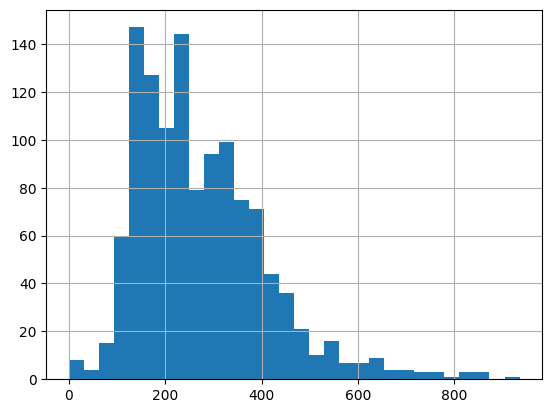

In [58]:
# Creo una columna overview_length
movies_df["overview_length"] = movies_df["overview"].fillna("").str.len()

movies_df["overview_length"].hist(bins=30)

In [60]:
# Cuántas son muy cortas
(movies_df["overview_length"] < 50).sum() # Obtengo np.int64(9)

np.int64(9)

In [61]:
# Cuántas son muy largas
(movies_df["overview_length"] > 500).sum() # Obtengo 66

np.int64(71)

### Distribución de la longitud de las sinopsis

La distribución de la longitud de las sinopsis muestra que la mayoría de las películas se concentran entre 150 y 350 caracteres, lo cual indica una cantidad adecuada de información textual para tareas de recuperación.

Se observa además una cola hacia la derecha, con algunas sinopsis considerablemente más largas, así como un pequeño número de casos con descripciones muy cortas o vacías.

En particular:
- Se identificaron 9 sinopsis muy cortas
- Se identificaron 66 sinopsis considerablemente largas

Esta variabilidad es esperable en datos reales y será considerada en etapas posteriores del proyecto.

Este análisis impacta directamente en:

👉 **TF-IDF**

*   textos largos → más términos → más peso
*   textos cortos → menos señal


👉 **Embeddings**

*   textos largos → mejor contexto
*   textos cortos → embeddings más pobres

In [62]:
# Obtener detalle de una película
def get_movie_details(movie_id: int, language: str = "en-US") -> Dict[str, Any]:
    """
    Obtiene la información detallada de una película a partir de su id.
    Parámetros:
    - movie_id: identificador de la película en TMDB
    - language: idioma en el que se solicita la información

    Retorna:
    - Un diccionario con los datos detallados de la película
    """
    return tmdb_get(f"/movie/{movie_id}", params={"language": language})

In [63]:
# Probamos con una película
sample_id = int(movies_df.loc[2, "id"])
sample_detail = get_movie_details(sample_id)

sample_detail.keys() #Veo los atributos posibles de una película

dict_keys(['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'origin_country', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count'])

In [64]:
sample_detail["title"], sample_detail["genres"], sample_detail["overview"], sample_detail["tagline"], sample_detail["spoken_languages"]

('Mike & Nick & Nick & Alice',
 [{'id': 35, 'name': 'Comedy'},
  {'id': 878, 'name': 'Science Fiction'},
  {'id': 80, 'name': 'Crime'}],
 'Two gangsters and the woman they love try to survive the most dangerous night of their lives. As if that wasn’t enough, there’s one wild ingredient added to the mix: a time machine.',
 'A time-traveling, double-crossing, ass-kicking comedy.',
 [{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}])

### Análisis de atributos adicionales

Se exploraron otros campos disponibles en la API, como `tagline` y `spoken_languages`.

El campo `tagline` corresponde a una frase breve de carácter promocional. Si bien puede aportar información semántica, no está presente en todos los casos y su contenido suele ser menos descriptivo que la sinopsis.

Por otro lado, `spoken_languages` indica el idioma hablado en la película, lo cual resulta útil como metadata, pero no aporta directamente al contenido semántico necesario para la búsqueda.

En esta etapa, se priorizan los campos que contienen información descriptiva más rica, como `overview`, `genres`, `keywords` y `cast`. Sin embargo, estos atributos podrán ser considerados en etapas posteriores para mejorar el sistema.

In [65]:
# Keywords y créditos
def get_movie_keywords(movie_id: int) -> Dict[str, Any]:
    """
    Obtiene las keywords asociadas a una película desde TMDB.

    Parámetros:
    - movie_id: identificador de la película en TMDB

    Retorna:
    - Un diccionario con las keywords de la película.
      La estructura incluye una lista bajo la clave 'keywords',
      donde cada elemento tiene información como el nombre de la keyword.
    """
    return tmdb_get(f"/movie/{movie_id}/keywords")


def get_movie_credits(movie_id: int) -> Dict[str, Any]:
    """
    Obtiene los créditos de una película desde TMDB.

    Parámetros:
    - movie_id: identificador de la película en TMDB

    Retorna:
    - Un diccionario con información de casting y crew.
      Incluye claves como:
        - 'cast': lista de actores
        - 'crew': equipo técnico (director, etc.)
    """
    return tmdb_get(f"/movie/{movie_id}/credits")

In [66]:
# Probamos con una película
keywords = get_movie_keywords(sample_id)
credits = get_movie_credits(sample_id)

# Extraemos información relevante
keyword_names = [k.get("name") for k in keywords.get("keywords", []) if k.get("name")] #evita errores si falta "name"
top_cast = [c.get("name") for c in credits.get("cast", [])[:5] if c.get("name")] #evita errores si falta "name"

print("Keywords:", keyword_names)
print("Cast:", top_cast)

Keywords: ['time travel', 'time machine', 'buddy comedy', 'violence action', 'witty', 'action sequence', 'action film', 'action choreography', 'sci-fi action', 'multi‑timeline characters', 'unpredictable situations', 'fractured friendships', 'buddy action']
Cast: ['James Marsden', 'Vince Vaughn', 'Eiza González', 'Keith David', 'Jimmy Tatro']


### Extracción de información relevante

Se extrajeron las keywords y el elenco principal de cada película a partir de la información obtenida desde la API.

Las keywords permiten capturar temas específicos asociados a la película (por ejemplo, "time travel", "buddy comedy"), mientras que el elenco aporta información sobre los actores principales.

Dado que el listado completo de actores puede ser extenso, se seleccionaron únicamente los primeros 5, correspondientes a los roles principales.

Esta información será utilizada posteriormente para enriquecer la representación textual de cada película.

In [67]:
# Dataset enriquecido prueba
def build_enriched_dataset(movie_ids: List[int]) -> pd.DataFrame:
    """
    Construye dataset enriquecido con:
    - detalles generales
    - keywords
    - actores
    """
    rows = []

    for movie_id in movie_ids:
        try:
            detail = get_movie_details(movie_id)
            keywords = get_movie_keywords(movie_id)
            credits = get_movie_credits(movie_id)

            rows.append({
                "id": detail.get("id"),
                "title": detail.get("title"),
                "overview": detail.get("overview"),
                "genres": [g["name"] for g in detail.get("genres", [])],
                "keywords": [k["name"] for k in keywords.get("keywords", [])],
                "cast": [c["name"] for c in credits.get("cast", [])[:5]]
            })

            time.sleep(0.2)

        except Exception as e:
            print(f"Error con {movie_id}: {e}")

    return pd.DataFrame(rows)

In [31]:
# Importante: probar con pocas películas primero
mini_ids = movies_df["id"].sample(20, random_state=42).tolist()

mini_df = build_enriched_dataset(mini_ids)
mini_df.head()

,id,title,overview,genres,keywords,cast
0,449443,Den of Thieves,A gritty crime saga which follows the lives of...,"[Crime, Thriller, Action]","[police brutality, detective, fbi, assault rif...","[Gerard Butler, Pablo Schreiber, O'Shea Jackso..."
1,198184,Chappie,Every child comes into the world full of promi...,"[Crime, Action, Science Fiction]","[future, android, artificial intelligence (a.i...","[Sharlto Copley, Dev Patel, Hugh Jackman, Ninj..."
2,1234821,Jurassic World Rebirth,Five years after the events of Jurassic World ...,"[Science Fiction, Adventure, Action]","[island, secret mission, tyrannosaurus rex, sp...","[Scarlett Johansson, Mahershala Ali, Jonathan ..."
3,1242419,Roofman,A former Army Ranger and struggling father tur...,"[Crime, Comedy, Drama]","[based on true story, fugitive, true crime, to...","[Channing Tatum, Kirsten Dunst, Ben Mendelsohn..."
4,1306368,The Rip,Trust frays when a team of Miami cops discover...,"[Action, Thriller, Crime]","[miami, florida, police, investigation, shooto...","[Matt Damon, Ben Affleck, Teyana Taylor, Steve..."


### Construcción de la representación textual

En esta etapa se construye una representación textual unificada para cada película, combinando distintos atributos disponibles en el dataset.

La representación actual incluye:
- título (`title`)
- sinopsis (`overview`)
- géneros (`genres`)
- keywords (`keywords`)
- elenco principal (`cast`)

El objetivo es generar un texto que capture tanto el contenido narrativo como información estructurada relevante, de manera que pueda ser utilizado posteriormente en modelos de búsqueda léxica (TF-IDF) y semántica (embeddings).

#### Consideraciones de diseño

La construcción del texto implica decisiones importantes sobre qué información incluir y cómo representarla. En particular:

- **Importancia relativa de los campos**: no todos los atributos aportan el mismo valor semántico. Por ejemplo, la sinopsis suele contener la mayor parte de la información descriptiva, mientras que el elenco o las keywords pueden complementar el contexto.

- **Balance entre información y ruido**: incluir más campos puede enriquecer la representación, pero también introducir ruido si los datos no son relevantes o son redundantes.

- **Formato del texto**: actualmente los campos se concatenan en un único string. Alternativamente, podría utilizarse una estructura más explícita (por ejemplo, con etiquetas como "Title:", "Genres:", etc.) para facilitar la interpretación del modelo.

#### Estrategias alternativas

Se pueden considerar distintas variantes para la representación textual, que podrán evaluarse en etapas posteriores:

1. **Representación mínima**  
   Utilizar únicamente título y sinopsis:
   - menor ruido
   - baseline simple para comparación

2. **Representación enriquecida (actual)**  
   Combinar múltiples atributos (géneros, keywords, cast):
   - mayor contexto semántico
   - potencial mejora en embeddings

3. **Evaluación comparativa de representaciones**  
   Mantener distintas versiones del texto y comparar su impacto en:
   - Precision@K
   - calidad de los resultados

Este tipo de análisis permitirá entender qué combinación de atributos produce mejores resultados en el sistema de búsqueda.

Estas decisiones forman parte del proceso de feature engineering textual, el cual tiene un impacto directo en el desempeño de los sistemas de recuperación de información.

In [36]:
# Construir texto para embeddings
def build_text(row):
    """
    Construye una representación textual unificada de una película
    a partir de sus distintos atributos.

    Combina:
    - título
    - sinopsis
    - géneros
    - keywords
    - elenco

    Retorna:
    - Un string con toda la información concatenada
    """
    parts = []

    # Título
    title = row.get("title")
    if pd.notna(title) and str(title).strip():
        parts.append(str(title).strip())

    # Overview
    overview = row.get("overview")
    if pd.notna(overview) and str(overview).strip():
        parts.append(str(overview).strip())

    # Géneros
    genres = row.get("genres", [])
    if isinstance(genres, list) and genres:
        parts.append("Genres: " + ", ".join(genres))

    # Keywords
    keywords = row.get("keywords", [])
    if isinstance(keywords, list) and keywords:
        parts.append("Keywords: " + ", ".join(keywords))

    # Cast
    cast = row.get("cast", [])
    if isinstance(cast, list) and cast:
        parts.append("Cast: " + ", ".join(cast))

    return " | ".join(parts)

### Construcción del texto final

En esta etapa se construye una representación textual unificada para cada película a partir de sus distintos atributos.

Se aplica la función `build_text` a cada fila del dataset para transformar la información estructurada (columnas) en un único texto por película.

Este proceso convierte el dataset en un corpus de documentos, que será utilizado como entrada para los modelos de búsqueda:

- TF-IDF (baseline léxico)
- Embeddings (búsqueda semántica)

Cada documento combina información descriptiva (sinopsis) con atributos adicionales (géneros, keywords, elenco), con el objetivo de enriquecer la representación semántica.

In [35]:
mini_df["search_text"] = mini_df.apply(build_text, axis=1) #Para cada fila del DataFrame, aplica build_text y guardá el resultado en una nueva columna(axis=1 trabaja fila por fila)

mini_df[["title", "search_text"]].head(3)

,title,search_text
0,Den of Thieves,Den of Thieves | A gritty crime saga which fol...
1,Chappie,Chappie | Every child comes into the world ful...
2,Jurassic World Rebirth,Jurassic World Rebirth | Five years after the ...


### Guardado del dataset

El dataset generado se guarda en dos formatos:

- **CSV**: facilita la inspección manual y la compatibilidad con otras herramientas.
- **Parquet**: permite preservar los tipos de datos (por ejemplo, listas en columnas como géneros, keywords y elenco) y ofrece mayor eficiencia en términos de almacenamiento y velocidad de lectura.

Esto permite utilizar el formato más adecuado según el contexto en etapas posteriores del proyecto.

In [40]:
# Guardar dataset para uso en próximos notebooks
mini_df.to_csv("movies_mini.csv", index=False)
mini_df.to_parquet("movies_mini.parquet", index=False)

print("Dataset guardado en CSV y Parquet correctamente")

Dataset guardado en CSV y Parquet correctamente


In [41]:
# Verificación de carga
df_check = pd.read_parquet("movies_mini.parquet")
df_check.head(2)

,id,title,overview,genres,keywords,cast,text_for_embedding,search_text
0,449443,Den of Thieves,A gritty crime saga which follows the lives of...,"[Crime, Thriller, Action]","[police brutality, detective, fbi, assault rif...","[Gerard Butler, Pablo Schreiber, O'Shea Jackso...",Den of Thieves | A gritty crime saga which fol...,Den of Thieves | A gritty crime saga which fol...
1,198184,Chappie,Every child comes into the world full of promi...,"[Crime, Action, Science Fiction]","[future, android, artificial intelligence (a.i...","[Sharlto Copley, Dev Patel, Hugh Jackman, Ninj...",Chappie | Every child comes into the world ful...,Chappie | Every child comes into the world ful...


## Conclusiones de esta etapa

En este notebook se construyó un dataset inicial de películas a partir de la API de TMDB, que servirá como base para el sistema de búsqueda.

Durante esta etapa se realizaron las siguientes tareas:
- Extracción de datos utilizando la API de TMDB
- Exploración inicial del dataset para analizar su calidad y características
- Enriquecimiento de la información con detalles, keywords y elenco
- Construcción de una representación textual unificada por película

El dataset resultante permite transformar la información estructurada en un corpus de documentos de texto, adecuado para tareas de recuperación de información.

Si bien el dataset se basa en películas populares (lo que introduce cierto sesgo hacia contenido reciente y mainstream), resulta adecuado para prototipar el sistema. En etapas posteriores se evaluará el impacto de construir un corpus más diverso y balanceado.

Este dataset será utilizado en las siguientes etapas para:
- Implementar un baseline léxico con TF-IDF
- Generar embeddings para búsqueda semántica
- Comparar ambos enfoques mediante métricas como Precision@K